# Nature - publication statistics - Europe

## Initialize GBQ SQL query environment

In [1]:
# Authenticate
from google.colab import auth
auth.authenticate_user()

In [2]:
# Initialize client
from google.cloud import bigquery
from google.cloud.bigquery import magics

project_id = "cwts-leiden"

client = bigquery.Client(project=project_id, location="EU")

magics.context.project = project_id

In [3]:
# Create session
job_config = bigquery.QueryJobConfig(create_session=True)
session_job = client.query("select 1", job_config=job_config)
session_job.result()
session_id = session_job.session_info.session_id

job_config_with_session = bigquery.QueryJobConfig(
    connection_properties=[
        bigquery.query.ConnectionProperty(key="session_id", value=session_id)
    ]
)

magics.context.default_query_job_config = job_config_with_session

## Collect publication and country data

In [ ]:
%%bigquery

-- Select core publications from the CWTS OpenAlex dataset on GBQ. The
-- methodology for identifying core publications in OpenAlex is outlined in
-- https://doi.org/10.5281/zenodo.17200830.

create or replace temp table pub as
select
  a.work_id,
  a.pub_year
from `cwts-leiden.openalex_2025aug.work` as a
join `cwts-leiden.openalex_2025aug_core.work` as b on a.work_id = b.work_id
where a.pub_year between 2006 and 2024
  and a.is_retracted = false
  and b.is_core_work = true;


-- Collect citation impact data from the CWTS Leiden Ranking Open Edition
-- dataset on GBQ.

create or replace temp table pub_impact_indicators as
select
  a.work_id,
  b.pub_year,
  (a.period_begin_year + 4) - b.pub_year as cit_window,
  a.cs,
  a.ncs,
  a.p_top_1,
  a.p_top_5,
  a.p_top_10,
  a.p_top_50
from `cwts-leiden.leiden_ranking_open_edition_2025.pub_impact_indicators` as a
join `cwts-leiden.leiden_ranking_open_edition_2025.pub` as b on a.work_id = b.work_id
where a.period_begin_year between 2006 and 2020
  and a.core_pubs_only = true
  and (
    a.period_begin_year = b.pub_year
    or (a.period_begin_year = 2020 and b.pub_year = 2021)
    or (a.period_begin_year = 2020 and b.pub_year = 2022)
    or (a.period_begin_year = 2020 and b.pub_year = 2023)
  );


-- Link publications to countries based on affiliated institutions and calculate
-- the weight of linked countries based on the number of affiliated authors.

create or replace temp table pub_n_authors as
select
  a.work_id,
  count(*) as n_authors
from `cwts-leiden.openalex_2025aug.work_author` as a
join pub as b on a.work_id = b.work_id
group by a.work_id;

create or replace temp table pub_author_affiliation as
select
  a.work_id,
  a.author_seq,
  a.affiliation_seq,
  1.0 / (
    b.n_authors * count(*) over (partition by a.work_id, a.author_seq)
  ) as weight
from `cwts-leiden.openalex_2025aug.work_author_affiliation` as a
join pub_n_authors as b on a.work_id = b.work_id;

create or replace temp table pub_author_affiliation_institution as
select
  a.work_id,
  a.author_seq,
  a.affiliation_seq,
  b.institution_id,
  a.weight * (
    1.0 / count(*) over (partition by a.work_id, a.author_seq, a.affiliation_seq)
  ) as weight
from pub_author_affiliation as a
join `cwts-leiden.openalex_2025aug.work_affiliation_institution` as b
  on a.work_id = b.work_id and a.affiliation_seq = b.affiliation_seq;

-- Map Hong Kong and Macao to China.
create or replace temp table country as
select
  country_iso_alpha2_code,
  country_iso_alpha2_code as cleaned_country_iso_alpha2_code
from `cwts-leiden.openalex_2025aug.country`
where country_iso_alpha2_code not in ('cn', 'hk', 'mo')
union all
select
  country_iso_alpha2_code,
  'cn' as cleaned_country_iso_alpha2_code
from `cwts-leiden.openalex_2025aug.country`
where country_iso_alpha2_code in ('cn', 'hk', 'mo');

create or replace temp table pub_country as
select
  a.work_id,
  c.cleaned_country_iso_alpha2_code as country_code,
  sum(a.weight) as weight
from pub_author_affiliation_institution as a
join `cwts-leiden.openalex_2025aug.institution` as b on a.institution_id = b.institution_id
join country as c on b.country_iso_alpha2_code = c.country_iso_alpha2_code
group by a.work_id, c.cleaned_country_iso_alpha2_code;

## Create different groupings of European countries

In [ ]:
%%bigquery

-- EU-27 countries.
create or replace temp table eu27 as
select *
from unnest([
  struct('AT' as country_code, 'Austria' as country),
  ('BE', 'Belgium'),
  ('BG', 'Bulgaria'),
  ('HR', 'Croatia'),
  ('CY', 'Cyprus'),
  ('CZ', 'Czechia'),
  ('DK', 'Denmark'),
  ('EE', 'Estonia'),
  ('FI', 'Finland'),
  ('FR', 'France'),
  ('DE', 'Germany'),
  ('GR', 'Greece'),
  ('HU', 'Hungary'),
  ('IE', 'Ireland'),
  ('IT', 'Italy'),
  ('LV', 'Latvia'),
  ('LT', 'Lithuania'),
  ('LU', 'Luxembourg'),
  ('MT', 'Malta'),
  ('NL', 'Netherlands'),
  ('PL', 'Poland'),
  ('PT', 'Portugal'),
  ('RO', 'Romania'),
  ('SK', 'Slovakia'),
  ('SI', 'Slovenia'),
  ('ES', 'Spain'),
  ('SE', 'Sweden')
]);

create or replace temp table pub_eu27 as
select a.work_id, sum(a.weight) as weight
from pub_country as a
join eu27 as b on a.country_code = b.country_code
group by a.work_id;

-- EU-27 countries + non-EU European nations.
create or replace temp table europe as
select *
from eu27
union all
select *
from unnest([
  -- Non-EU Western & Northern Europe
  struct('GB', 'United Kingdom'),
  ('NO', 'Norway'),
  ('CH', 'Switzerland'),
  ('IS', 'Iceland'),

  -- Non-EU Eastern Europe & Balkans
  ('UA', 'Ukraine'),
  ('BY', 'Belarus'),
  ('MD', 'Moldova'),
  ('AL', 'Albania'),
  ('BA', 'Bosnia and Herzegovina'),
  ('ME', 'Montenegro'),
  ('MK', 'North Macedonia'),
  ('RS', 'Serbia'),
  ('XK', 'Kosovo'),

  -- European microstates
  ('AD', 'Andorra'),
  ('LI', 'Liechtenstein'),
  ('MC', 'Monaco'),
  ('SM', 'San Marino'),
  ('VA', 'Vatican City')
]);

create or replace temp table pub_europe as
select a.work_id, sum(a.weight) as weight
from pub_country as a
join europe as b on a.country_code = b.country_code
group by a.work_id;

## Calculate the proportion of publications per year for different countries and country groupings

### Full counting

In [ ]:
%%bigquery df_full_p

with full_p_country as (
  select
    a.pub_year,
    count(distinct a.work_id) as p,
    sum(case when b.country_code = 'CN' then 1 else 0 end) as p_china,
    sum(case when b.country_code = 'US' then 1 else 0 end) as p_us,
    sum(case when b.country_code = 'AT' then 1 else 0 end) as p_austria,
    sum(case when b.country_code = 'BE' then 1 else 0 end) as p_belgium,
    sum(case when b.country_code = 'BG' then 1 else 0 end) as p_bulgaria,
    sum(case when b.country_code = 'CY' then 1 else 0 end) as p_cyprus,
    sum(case when b.country_code = 'CZ' then 1 else 0 end) as p_czechia,
    sum(case when b.country_code = 'DE' then 1 else 0 end) as p_germany,
    sum(case when b.country_code = 'DK' then 1 else 0 end) as p_denmark,
    sum(case when b.country_code = 'EE' then 1 else 0 end) as p_estonia,
    sum(case when b.country_code = 'ES' then 1 else 0 end) as p_spain,
    sum(case when b.country_code = 'FI' then 1 else 0 end) as p_finland,
    sum(case when b.country_code = 'FR' then 1 else 0 end) as p_france,
    sum(case when b.country_code = 'GR' then 1 else 0 end) as p_greece,
    sum(case when b.country_code = 'HR' then 1 else 0 end) as p_croatia,
    sum(case when b.country_code = 'HU' then 1 else 0 end) as p_hungary,
    sum(case when b.country_code = 'IE' then 1 else 0 end) as p_ireland,
    sum(case when b.country_code = 'IT' then 1 else 0 end) as p_italy,
    sum(case when b.country_code = 'LT' then 1 else 0 end) as p_lithuania,
    sum(case when b.country_code = 'LU' then 1 else 0 end) as p_luxembourg,
    sum(case when b.country_code = 'LV' then 1 else 0 end) as p_latvia,
    sum(case when b.country_code = 'MT' then 1 else 0 end) as p_malta,
    sum(case when b.country_code = 'NL' then 1 else 0 end) as p_netherlands,
    sum(case when b.country_code = 'PL' then 1 else 0 end) as p_poland,
    sum(case when b.country_code = 'PT' then 1 else 0 end) as p_portugal,
    sum(case when b.country_code = 'RO' then 1 else 0 end) as p_romania,
    sum(case when b.country_code = 'SE' then 1 else 0 end) as p_sweden,
    sum(case when b.country_code = 'SI' then 1 else 0 end) as p_slovenia,
    sum(case when b.country_code = 'SK' then 1 else 0 end) as p_slovakia,
    sum(case when b.country_code = 'GB' then 1 else 0 end) as p_uk,
    sum(case when b.country_code = 'CH' then 1 else 0 end) as p_switzerland
  from pub a
  join pub_country b on a.work_id = b.work_id
  group by a.pub_year
),
full_p_eu27 as (
  select
    a.pub_year,
    count(distinct a.work_id) as p_eu27
  from pub a
  join pub_eu27 b on a.work_id = b.work_id
  group by a.pub_year
),
full_p_europe as (
  select
    a.pub_year,
    count(distinct a.work_id) as p_europe
  from pub a
  join pub_europe b on a.work_id = b.work_id
  group by a.pub_year
)
select
  a.pub_year,
  a.p,
  a.p_china,
  a.p_us,
  b.p_eu27,
  c.p_europe,
  a.p_austria,
  a.p_belgium,
  a.p_bulgaria,
  a.p_cyprus,
  a.p_czechia,
  a.p_germany,
  a.p_denmark,
  a.p_estonia,
  a.p_spain,
  a.p_finland,
  a.p_france,
  a.p_greece,
  a.p_croatia,
  a.p_hungary,
  a.p_ireland,
  a.p_italy,
  a.p_lithuania,
  a.p_luxembourg,
  a.p_latvia,
  a.p_malta,
  a.p_netherlands,
  a.p_poland,
  a.p_portugal,
  a.p_romania,
  a.p_sweden,
  a.p_slovenia,
  a.p_slovakia,
  a.p_uk,
  a.p_switzerland,
  cast(a.p_china as float64) / a.p as pp_china,
  cast(a.p_us as float64) / a.p as pp_us,
  cast(b.p_eu27 as float64) / a.p as pp_eu27,
  cast(c.p_europe as float64) / a.p as pp_europe,
  cast(a.p_austria as float64) / a.p as pp_austria,
  cast(a.p_belgium as float64) / a.p as pp_belgium,
  cast(a.p_bulgaria as float64) / a.p as pp_bulgaria,
  cast(a.p_cyprus as float64) / a.p as pp_cyprus,
  cast(a.p_czechia as float64) / a.p as pp_czechia,
  cast(a.p_germany as float64) / a.p as pp_germany,
  cast(a.p_denmark as float64) / a.p as pp_denmark,
  cast(a.p_estonia as float64) / a.p as pp_estonia,
  cast(a.p_spain as float64) / a.p as pp_spain,
  cast(a.p_finland as float64) / a.p as pp_finland,
  cast(a.p_france as float64) / a.p as pp_france,
  cast(a.p_greece as float64) / a.p as pp_greece,
  cast(a.p_croatia as float64) / a.p as pp_croatia,
  cast(a.p_hungary as float64) / a.p as pp_hungary,
  cast(a.p_ireland as float64) / a.p as pp_ireland,
  cast(a.p_italy as float64) / a.p as pp_italy,
  cast(a.p_lithuania as float64) / a.p as pp_lithuania,
  cast(a.p_luxembourg as float64) / a.p as pp_luxembourg,
  cast(a.p_latvia as float64) / a.p as pp_latvia,
  cast(a.p_malta as float64) / a.p as pp_malta,
  cast(a.p_netherlands as float64) / a.p as pp_netherlands,
  cast(a.p_poland as float64) / a.p as pp_poland,
  cast(a.p_portugal as float64) / a.p as pp_portugal,
  cast(a.p_romania as float64) / a.p as pp_romania,
  cast(a.p_sweden as float64) / a.p as pp_sweden,
  cast(a.p_slovenia as float64) / a.p as pp_slovenia,
  cast(a.p_slovakia as float64) / a.p as pp_slovakia,
  cast(a.p_uk as float64) / a.p as pp_uk,
  cast(a.p_switzerland as float64) / a.p as pp_switzerland
from full_p_country a
join full_p_eu27 b on a.pub_year = b.pub_year
join full_p_europe c on a.pub_year = c.pub_year
order by a.pub_year desc;

In [ ]:
%%bigquery df_full_p_top_10

with full_p_top_10 as (
  select
    pub_year,
    sum(p_top_10) as p_top_10
  from (
    select distinct
      a.work_id,
      a.pub_year,
      a.p_top_10
    from pub_impact_indicators a
    join pub_country b on a.work_id = b.work_id
  )
  group by pub_year
),
full_p_top_10_country as (
  select
    a.pub_year,
    sum(case when b.country_code = 'CN' then a.p_top_10 else 0 end) as p_top_10_china,
    sum(case when b.country_code = 'US' then a.p_top_10 else 0 end) as p_top_10_us,
    sum(case when b.country_code = 'AT' then a.p_top_10 else 0 end) as p_top_10_austria,
    sum(case when b.country_code = 'BE' then a.p_top_10 else 0 end) as p_top_10_belgium,
    sum(case when b.country_code = 'BG' then a.p_top_10 else 0 end) as p_top_10_bulgaria,
    sum(case when b.country_code = 'CY' then a.p_top_10 else 0 end) as p_top_10_cyprus,
    sum(case when b.country_code = 'CZ' then a.p_top_10 else 0 end) as p_top_10_czechia,
    sum(case when b.country_code = 'DE' then a.p_top_10 else 0 end) as p_top_10_germany,
    sum(case when b.country_code = 'DK' then a.p_top_10 else 0 end) as p_top_10_denmark,
    sum(case when b.country_code = 'EE' then a.p_top_10 else 0 end) as p_top_10_estonia,
    sum(case when b.country_code = 'ES' then a.p_top_10 else 0 end) as p_top_10_spain,
    sum(case when b.country_code = 'FI' then a.p_top_10 else 0 end) as p_top_10_finland,
    sum(case when b.country_code = 'FR' then a.p_top_10 else 0 end) as p_top_10_france,
    sum(case when b.country_code = 'GR' then a.p_top_10 else 0 end) as p_top_10_greece,
    sum(case when b.country_code = 'HR' then a.p_top_10 else 0 end) as p_top_10_croatia,
    sum(case when b.country_code = 'HU' then a.p_top_10 else 0 end) as p_top_10_hungary,
    sum(case when b.country_code = 'IE' then a.p_top_10 else 0 end) as p_top_10_ireland,
    sum(case when b.country_code = 'IT' then a.p_top_10 else 0 end) as p_top_10_italy,
    sum(case when b.country_code = 'LT' then a.p_top_10 else 0 end) as p_top_10_lithuania,
    sum(case when b.country_code = 'LU' then a.p_top_10 else 0 end) as p_top_10_luxembourg,
    sum(case when b.country_code = 'LV' then a.p_top_10 else 0 end) as p_top_10_latvia,
    sum(case when b.country_code = 'MT' then a.p_top_10 else 0 end) as p_top_10_malta,
    sum(case when b.country_code = 'NL' then a.p_top_10 else 0 end) as p_top_10_netherlands,
    sum(case when b.country_code = 'PL' then a.p_top_10 else 0 end) as p_top_10_poland,
    sum(case when b.country_code = 'PT' then a.p_top_10 else 0 end) as p_top_10_portugal,
    sum(case when b.country_code = 'RO' then a.p_top_10 else 0 end) as p_top_10_romania,
    sum(case when b.country_code = 'SE' then a.p_top_10 else 0 end) as p_top_10_sweden,
    sum(case when b.country_code = 'SI' then a.p_top_10 else 0 end) as p_top_10_slovenia,
    sum(case when b.country_code = 'SK' then a.p_top_10 else 0 end) as p_top_10_slovakia,
    sum(case when b.country_code = 'GB' then a.p_top_10 else 0 end) as p_top_10_uk,
    sum(case when b.country_code = 'CH' then a.p_top_10 else 0 end) as p_top_10_switzerland
  from pub_impact_indicators a
  join pub_country b on a.work_id = b.work_id
  group by a.pub_year
),
full_p_top_10_eu27 as (
  select
    pub_year,
    sum(p_top_10) as p_top_10_eu27
  from (
    select distinct
      a.work_id,
      a.pub_year,
      a.p_top_10
    from pub_impact_indicators a
    join pub_eu27 b on a.work_id = b.work_id
  )
  group by pub_year
),
full_p_top_10_europe as (
  select
    pub_year,
    sum(p_top_10) as p_top_10_europe
  from (
    select distinct
      a.work_id,
      a.pub_year,
      a.p_top_10
    from pub_impact_indicators a
    join pub_europe b on a.work_id = b.work_id
  )
  group by pub_year
)
select
  a.pub_year,
  a.p_top_10,
  b.p_top_10_china,
  b.p_top_10_us,
  c.p_top_10_eu27,
  d.p_top_10_europe,
  b.p_top_10_austria,
  b.p_top_10_belgium,
  b.p_top_10_bulgaria,
  b.p_top_10_cyprus,
  b.p_top_10_czechia,
  b.p_top_10_germany,
  b.p_top_10_denmark,
  b.p_top_10_estonia,
  b.p_top_10_spain,
  b.p_top_10_finland,
  b.p_top_10_france,
  b.p_top_10_greece,
  b.p_top_10_croatia,
  b.p_top_10_hungary,
  b.p_top_10_ireland,
  b.p_top_10_italy,
  b.p_top_10_lithuania,
  b.p_top_10_luxembourg,
  b.p_top_10_latvia,
  b.p_top_10_malta,
  b.p_top_10_netherlands,
  b.p_top_10_poland,
  b.p_top_10_portugal,
  b.p_top_10_romania,
  b.p_top_10_sweden,
  b.p_top_10_slovenia,
  b.p_top_10_slovakia,
  b.p_top_10_uk,
  b.p_top_10_switzerland,
  cast(b.p_top_10_china as float64) / a.p_top_10 as pp_top_10_china,
  cast(b.p_top_10_us as float64) / a.p_top_10 as pp_top_10_us,
  cast(c.p_top_10_eu27 as float64) / a.p_top_10 as pp_top_10_eu27,
  cast(d.p_top_10_europe as float64) / a.p_top_10 as pp_top_10_europe,
  cast(b.p_top_10_austria as float64) / a.p_top_10 as pp_top_10_austria,
  cast(b.p_top_10_belgium as float64) / a.p_top_10 as pp_top_10_belgium,
  cast(b.p_top_10_bulgaria as float64) / a.p_top_10 as pp_top_10_bulgaria,
  cast(b.p_top_10_cyprus as float64) / a.p_top_10 as pp_top_10_cyprus,
  cast(b.p_top_10_czechia as float64) / a.p_top_10 as pp_top_10_czechia,
  cast(b.p_top_10_germany as float64) / a.p_top_10 as pp_top_10_germany,
  cast(b.p_top_10_denmark as float64) / a.p_top_10 as pp_top_10_denmark,
  cast(b.p_top_10_estonia as float64) / a.p_top_10 as pp_top_10_estonia,
  cast(b.p_top_10_spain as float64) / a.p_top_10 as pp_top_10_spain,
  cast(b.p_top_10_finland as float64) / a.p_top_10 as pp_top_10_finland,
  cast(b.p_top_10_france as float64) / a.p_top_10 as pp_top_10_france,
  cast(b.p_top_10_greece as float64) / a.p_top_10 as pp_top_10_greece,
  cast(b.p_top_10_croatia as float64) / a.p_top_10 as pp_top_10_croatia,
  cast(b.p_top_10_hungary as float64) / a.p_top_10 as pp_top_10_hungary,
  cast(b.p_top_10_ireland as float64) / a.p_top_10 as pp_top_10_ireland,
  cast(b.p_top_10_italy as float64) / a.p_top_10 as pp_top_10_italy,
  cast(b.p_top_10_lithuania as float64) / a.p_top_10 as pp_top_10_lithuania,
  cast(b.p_top_10_luxembourg as float64) / a.p_top_10 as pp_top_10_luxembourg,
  cast(b.p_top_10_latvia as float64) / a.p_top_10 as pp_top_10_latvia,
  cast(b.p_top_10_malta as float64) / a.p_top_10 as pp_top_10_malta,
  cast(b.p_top_10_netherlands as float64) / a.p_top_10 as pp_top_10_netherlands,
  cast(b.p_top_10_poland as float64) / a.p_top_10 as pp_top_10_poland,
  cast(b.p_top_10_portugal as float64) / a.p_top_10 as pp_top_10_portugal,
  cast(b.p_top_10_romania as float64) / a.p_top_10 as pp_top_10_romania,
  cast(b.p_top_10_sweden as float64) / a.p_top_10 as pp_top_10_sweden,
  cast(b.p_top_10_slovenia as float64) / a.p_top_10 as pp_top_10_slovenia,
  cast(b.p_top_10_slovakia as float64) / a.p_top_10 as pp_top_10_slovakia,
  cast(b.p_top_10_uk as float64) / a.p_top_10 as pp_top_10_uk,
  cast(b.p_top_10_switzerland as float64) / a.p_top_10 as pp_top_10_switzerland
from full_p_top_10 a
join full_p_top_10_country b on a.pub_year = b.pub_year
join full_p_top_10_eu27 c on a.pub_year = c.pub_year
join full_p_top_10_europe d on a.pub_year = d.pub_year
order by a.pub_year desc;

### Fractional counting

In [ ]:
%%bigquery df_frac_p

select
  a.pub_year,
  sum(case when b.country_code is not null then b.weight else 0 end) as p,
  sum(case when b.country_code in ('CN') then b.weight else 0 end) as p_china,
  sum(case when b.country_code in ('US') then b.weight else 0 end) as p_us,
  sum(case when c.country_code is not null then b.weight else 0 end) as p_eu27,
  sum(case when d.country_code is not null then b.weight else 0 end) as p_europe,
  sum(case when b.country_code in ('AT') then b.weight else 0 end) as p_austria,
  sum(case when b.country_code in ('BE') then b.weight else 0 end) as p_belgium,
  sum(case when b.country_code in ('BG') then b.weight else 0 end) as p_bulgaria,
  sum(case when b.country_code in ('CY') then b.weight else 0 end) as p_cyprus,
  sum(case when b.country_code in ('CZ') then b.weight else 0 end) as p_czechia,
  sum(case when b.country_code in ('DE') then b.weight else 0 end) as p_germany,
  sum(case when b.country_code in ('DK') then b.weight else 0 end) as p_denmark,
  sum(case when b.country_code in ('EE') then b.weight else 0 end) as p_estonia,
  sum(case when b.country_code in ('ES') then b.weight else 0 end) as p_spain,
  sum(case when b.country_code in ('FI') then b.weight else 0 end) as p_finland,
  sum(case when b.country_code in ('FR') then b.weight else 0 end) as p_france,
  sum(case when b.country_code in ('GR') then b.weight else 0 end) as p_greece,
  sum(case when b.country_code in ('HR') then b.weight else 0 end) as p_croatia,
  sum(case when b.country_code in ('HU') then b.weight else 0 end) as p_hungary,
  sum(case when b.country_code in ('IE') then b.weight else 0 end) as p_ireland,
  sum(case when b.country_code in ('IT') then b.weight else 0 end) as p_italy,
  sum(case when b.country_code in ('LT') then b.weight else 0 end) as p_lithuania,
  sum(case when b.country_code in ('LU') then b.weight else 0 end) as p_luxembourg,
  sum(case when b.country_code in ('LV') then b.weight else 0 end) as p_latvia,
  sum(case when b.country_code in ('MT') then b.weight else 0 end) as p_malta,
  sum(case when b.country_code in ('NL') then b.weight else 0 end) as p_netherlands,
  sum(case when b.country_code in ('PL') then b.weight else 0 end) as p_poland,
  sum(case when b.country_code in ('PT') then b.weight else 0 end) as p_portugal,
  sum(case when b.country_code in ('RO') then b.weight else 0 end) as p_romania,
  sum(case when b.country_code in ('SE') then b.weight else 0 end) as p_sweden,
  sum(case when b.country_code in ('SI') then b.weight else 0 end) as p_slovenia,
  sum(case when b.country_code in ('SK') then b.weight else 0 end) as p_slovakia,
  sum(case when b.country_code in ('GB') then b.weight else 0 end) as p_uk,
  sum(case when b.country_code in ('CH') then b.weight else 0 end) as p_switzerland,
  sum(case when b.country_code in ('CN') then b.weight else 0 end) /
    sum(case when b.country_code is not null then b.weight else 0 end) as pp_china,
  sum(case when b.country_code in ('US') then b.weight else 0 end) /
    sum(case when b.country_code is not null then b.weight else 0 end) as pp_us,
  sum(case when c.country_code is not null then b.weight else 0 end) /
    sum(case when b.country_code is not null then b.weight else 0 end) as pp_eu27,
  sum(case when d.country_code is not null then b.weight else 0 end) /
    sum(case when b.country_code is not null then b.weight else 0 end) as pp_europe,
  sum(case when b.country_code in ('AT') then b.weight else 0 end) /
    sum(case when b.country_code is not null then b.weight else 0 end) as pp_austria,
  sum(case when b.country_code in ('BE') then b.weight else 0 end) /
    sum(case when b.country_code is not null then b.weight else 0 end) as pp_belgium,
  sum(case when b.country_code in ('BG') then b.weight else 0 end) /
    sum(case when b.country_code is not null then b.weight else 0 end) as pp_bulgaria,
  sum(case when b.country_code in ('CY') then b.weight else 0 end) /
    sum(case when b.country_code is not null then b.weight else 0 end) as pp_cyprus,
  sum(case when b.country_code in ('CZ') then b.weight else 0 end) /
    sum(case when b.country_code is not null then b.weight else 0 end) as pp_czechia,
  sum(case when b.country_code in ('DE') then b.weight else 0 end) /
    sum(case when b.country_code is not null then b.weight else 0 end) as pp_germany,
  sum(case when b.country_code in ('DK') then b.weight else 0 end) /
    sum(case when b.country_code is not null then b.weight else 0 end) as pp_denmark,
  sum(case when b.country_code in ('EE') then b.weight else 0 end) /
    sum(case when b.country_code is not null then b.weight else 0 end) as pp_estonia,
  sum(case when b.country_code in ('ES') then b.weight else 0 end) /
    sum(case when b.country_code is not null then b.weight else 0 end) as pp_spain,
  sum(case when b.country_code in ('FI') then b.weight else 0 end) /
    sum(case when b.country_code is not null then b.weight else 0 end) as pp_finland,
  sum(case when b.country_code in ('FR') then b.weight else 0 end) /
    sum(case when b.country_code is not null then b.weight else 0 end) as pp_france,
  sum(case when b.country_code in ('GR') then b.weight else 0 end) /
    sum(case when b.country_code is not null then b.weight else 0 end) as pp_greece,
  sum(case when b.country_code in ('HR') then b.weight else 0 end) /
    sum(case when b.country_code is not null then b.weight else 0 end) as pp_croatia,
  sum(case when b.country_code in ('HU') then b.weight else 0 end) /
    sum(case when b.country_code is not null then b.weight else 0 end) as pp_hungary,
  sum(case when b.country_code in ('IE') then b.weight else 0 end) /
    sum(case when b.country_code is not null then b.weight else 0 end) as pp_ireland,
  sum(case when b.country_code in ('IT') then b.weight else 0 end) /
    sum(case when b.country_code is not null then b.weight else 0 end) as pp_italy,
  sum(case when b.country_code in ('LT') then b.weight else 0 end) /
    sum(case when b.country_code is not null then b.weight else 0 end) as pp_lithuania,
  sum(case when b.country_code in ('LU') then b.weight else 0 end) /
    sum(case when b.country_code is not null then b.weight else 0 end) as pp_luxembourg,
  sum(case when b.country_code in ('LV') then b.weight else 0 end) /
    sum(case when b.country_code is not null then b.weight else 0 end) as pp_latvia,
  sum(case when b.country_code in ('MT') then b.weight else 0 end) /
    sum(case when b.country_code is not null then b.weight else 0 end) as pp_malta,
  sum(case when b.country_code in ('NL') then b.weight else 0 end) /
    sum(case when b.country_code is not null then b.weight else 0 end) as pp_netherlands,
  sum(case when b.country_code in ('PL') then b.weight else 0 end) /
    sum(case when b.country_code is not null then b.weight else 0 end) as pp_poland,
  sum(case when b.country_code in ('PT') then b.weight else 0 end) /
    sum(case when b.country_code is not null then b.weight else 0 end) as pp_portugal,
  sum(case when b.country_code in ('RO') then b.weight else 0 end) /
    sum(case when b.country_code is not null then b.weight else 0 end) as pp_romania,
  sum(case when b.country_code in ('SE') then b.weight else 0 end) /
    sum(case when b.country_code is not null then b.weight else 0 end) as pp_sweden,
  sum(case when b.country_code in ('SI') then b.weight else 0 end) /
    sum(case when b.country_code is not null then b.weight else 0 end) as pp_slovenia,
  sum(case when b.country_code in ('SK') then b.weight else 0 end) /
    sum(case when b.country_code is not null then b.weight else 0 end) as pp_slovakia,
  sum(case when b.country_code in ('GB') then b.weight else 0 end) /
    sum(case when b.country_code is not null then b.weight else 0 end) as pp_uk,
  sum(case when b.country_code in ('CH') then b.weight else 0 end) /
    sum(case when b.country_code is not null then b.weight else 0 end) as pp_switzerland
from pub as a
join pub_country as b on a.work_id = b.work_id
left join eu27 as c on b.country_code = c.country_code
left join europe as d on b.country_code = d.country_code
group by a.pub_year
order by a.pub_year desc;

In [ ]:
%%bigquery df_frac_p_top_10

select
  a.pub_year,
  sum(case when b.country_code is not null then b.weight * a.p_top_10 else 0 end) as p_top_10,
  sum(case when b.country_code in ('CN') then b.weight * a.p_top_10 else 0 end) as p_top_10_china,
  sum(case when b.country_code in ('US') then b.weight * a.p_top_10 else 0 end) as p_top_10_us,
  sum(case when c.country_code is not null then b.weight * a.p_top_10 else 0 end) as p_top_10_eu27,
  sum(case when d.country_code is not null then b.weight * a.p_top_10 else 0 end) as p_top_10_europe,
  sum(case when b.country_code in ('AT') then b.weight * a.p_top_10 else 0 end) as p_top_10_austria,
  sum(case when b.country_code in ('BE') then b.weight * a.p_top_10 else 0 end) as p_top_10_belgium,
  sum(case when b.country_code in ('BG') then b.weight * a.p_top_10 else 0 end) as p_top_10_bulgaria,
  sum(case when b.country_code in ('CY') then b.weight * a.p_top_10 else 0 end) as p_top_10_cyprus,
  sum(case when b.country_code in ('CZ') then b.weight * a.p_top_10 else 0 end) as p_top_10_czechia,
  sum(case when b.country_code in ('DE') then b.weight * a.p_top_10 else 0 end) as p_top_10_germany,
  sum(case when b.country_code in ('DK') then b.weight * a.p_top_10 else 0 end) as p_top_10_denmark,
  sum(case when b.country_code in ('EE') then b.weight * a.p_top_10 else 0 end) as p_top_10_estonia,
  sum(case when b.country_code in ('ES') then b.weight * a.p_top_10 else 0 end) as p_top_10_spain,
  sum(case when b.country_code in ('FI') then b.weight * a.p_top_10 else 0 end) as p_top_10_finland,
  sum(case when b.country_code in ('FR') then b.weight * a.p_top_10 else 0 end) as p_top_10_france,
  sum(case when b.country_code in ('GR') then b.weight * a.p_top_10 else 0 end) as p_top_10_greece,
  sum(case when b.country_code in ('HR') then b.weight * a.p_top_10 else 0 end) as p_top_10_croatia,
  sum(case when b.country_code in ('HU') then b.weight * a.p_top_10 else 0 end) as p_top_10_hungary,
  sum(case when b.country_code in ('IE') then b.weight * a.p_top_10 else 0 end) as p_top_10_ireland,
  sum(case when b.country_code in ('IT') then b.weight * a.p_top_10 else 0 end) as p_top_10_italy,
  sum(case when b.country_code in ('LT') then b.weight * a.p_top_10 else 0 end) as p_top_10_lithuania,
  sum(case when b.country_code in ('LU') then b.weight * a.p_top_10 else 0 end) as p_top_10_luxembourg,
  sum(case when b.country_code in ('LV') then b.weight * a.p_top_10 else 0 end) as p_top_10_latvia,
  sum(case when b.country_code in ('MT') then b.weight * a.p_top_10 else 0 end) as p_top_10_malta,
  sum(case when b.country_code in ('NL') then b.weight * a.p_top_10 else 0 end) as p_top_10_netherlands,
  sum(case when b.country_code in ('PL') then b.weight * a.p_top_10 else 0 end) as p_top_10_poland,
  sum(case when b.country_code in ('PT') then b.weight * a.p_top_10 else 0 end) as p_top_10_portugal,
  sum(case when b.country_code in ('RO') then b.weight * a.p_top_10 else 0 end) as p_top_10_romania,
  sum(case when b.country_code in ('SE') then b.weight * a.p_top_10 else 0 end) as p_top_10_sweden,
  sum(case when b.country_code in ('SI') then b.weight * a.p_top_10 else 0 end) as p_top_10_slovenia,
  sum(case when b.country_code in ('SK') then b.weight * a.p_top_10 else 0 end) as p_top_10_slovakia,
  sum(case when b.country_code in ('GB') then b.weight * a.p_top_10 else 0 end) as p_top_10_uk,
  sum(case when b.country_code in ('CH') then b.weight * a.p_top_10 else 0 end) as p_top_10_switzerland,
  sum(case when b.country_code in ('CN') then b.weight * a.p_top_10 else 0 end) /
    sum(case when b.country_code is not null then b.weight * a.p_top_10 else 0 end) as pp_top_10_china,
  sum(case when b.country_code in ('US') then b.weight * a.p_top_10 else 0 end) /
    sum(case when b.country_code is not null then b.weight * a.p_top_10 else 0 end) as pp_top_10_us,
  sum(case when c.country_code is not null then b.weight * a.p_top_10 else 0 end) /
    sum(case when b.country_code is not null then b.weight * a.p_top_10 else 0 end) as pp_top_10_eu27,
  sum(case when d.country_code is not null then b.weight * a.p_top_10 else 0 end) /
    sum(case when b.country_code is not null then b.weight * a.p_top_10 else 0 end) as pp_top_10_europe,
  sum(case when b.country_code in ('AT') then b.weight * a.p_top_10 else 0 end) /
    sum(case when b.country_code is not null then b.weight * a.p_top_10 else 0 end) as pp_top_10_austria,
  sum(case when b.country_code in ('BE') then b.weight * a.p_top_10 else 0 end) /
    sum(case when b.country_code is not null then b.weight * a.p_top_10 else 0 end) as pp_top_10_belgium,
  sum(case when b.country_code in ('BG') then b.weight * a.p_top_10 else 0 end) /
    sum(case when b.country_code is not null then b.weight * a.p_top_10 else 0 end) as pp_top_10_bulgaria,
  sum(case when b.country_code in ('CY') then b.weight * a.p_top_10 else 0 end) /
    sum(case when b.country_code is not null then b.weight * a.p_top_10 else 0 end) as pp_top_10_cyprus,
  sum(case when b.country_code in ('CZ') then b.weight * a.p_top_10 else 0 end) /
    sum(case when b.country_code is not null then b.weight * a.p_top_10 else 0 end) as pp_top_10_czechia,
  sum(case when b.country_code in ('DE') then b.weight * a.p_top_10 else 0 end) /
    sum(case when b.country_code is not null then b.weight * a.p_top_10 else 0 end) as pp_top_10_germany,
  sum(case when b.country_code in ('DK') then b.weight * a.p_top_10 else 0 end) /
    sum(case when b.country_code is not null then b.weight * a.p_top_10 else 0 end) as pp_top_10_denmark,
  sum(case when b.country_code in ('EE') then b.weight * a.p_top_10 else 0 end) /
    sum(case when b.country_code is not null then b.weight * a.p_top_10 else 0 end) as pp_top_10_estonia,
  sum(case when b.country_code in ('ES') then b.weight * a.p_top_10 else 0 end) /
    sum(case when b.country_code is not null then b.weight * a.p_top_10 else 0 end) as pp_top_10_spain,
  sum(case when b.country_code in ('FI') then b.weight * a.p_top_10 else 0 end) /
    sum(case when b.country_code is not null then b.weight * a.p_top_10 else 0 end) as pp_top_10_finland,
  sum(case when b.country_code in ('FR') then b.weight * a.p_top_10 else 0 end) /
    sum(case when b.country_code is not null then b.weight * a.p_top_10 else 0 end) as pp_top_10_france,
  sum(case when b.country_code in ('GR') then b.weight * a.p_top_10 else 0 end) /
    sum(case when b.country_code is not null then b.weight * a.p_top_10 else 0 end) as pp_top_10_greece,
  sum(case when b.country_code in ('HR') then b.weight * a.p_top_10 else 0 end) /
    sum(case when b.country_code is not null then b.weight * a.p_top_10 else 0 end) as pp_top_10_croatia,
  sum(case when b.country_code in ('HU') then b.weight * a.p_top_10 else 0 end) /
    sum(case when b.country_code is not null then b.weight * a.p_top_10 else 0 end) as pp_top_10_hungary,
  sum(case when b.country_code in ('IE') then b.weight * a.p_top_10 else 0 end) /
    sum(case when b.country_code is not null then b.weight * a.p_top_10 else 0 end) as pp_top_10_ireland,
  sum(case when b.country_code in ('IT') then b.weight * a.p_top_10 else 0 end) /
    sum(case when b.country_code is not null then b.weight * a.p_top_10 else 0 end) as pp_top_10_italy,
  sum(case when b.country_code in ('LT') then b.weight * a.p_top_10 else 0 end) /
    sum(case when b.country_code is not null then b.weight * a.p_top_10 else 0 end) as pp_top_10_lithuania,
  sum(case when b.country_code in ('LU') then b.weight * a.p_top_10 else 0 end) /
    sum(case when b.country_code is not null then b.weight * a.p_top_10 else 0 end) as pp_top_10_luxembourg,
  sum(case when b.country_code in ('LV') then b.weight * a.p_top_10 else 0 end) /
    sum(case when b.country_code is not null then b.weight * a.p_top_10 else 0 end) as pp_top_10_latvia,
  sum(case when b.country_code in ('MT') then b.weight * a.p_top_10 else 0 end) /
    sum(case when b.country_code is not null then b.weight * a.p_top_10 else 0 end) as pp_top_10_malta,
  sum(case when b.country_code in ('NL') then b.weight * a.p_top_10 else 0 end) /
    sum(case when b.country_code is not null then b.weight * a.p_top_10 else 0 end) as pp_top_10_netherlands,
  sum(case when b.country_code in ('PL') then b.weight * a.p_top_10 else 0 end) /
    sum(case when b.country_code is not null then b.weight * a.p_top_10 else 0 end) as pp_top_10_poland,
  sum(case when b.country_code in ('PT') then b.weight * a.p_top_10 else 0 end) /
    sum(case when b.country_code is not null then b.weight * a.p_top_10 else 0 end) as pp_top_10_portugal,
  sum(case when b.country_code in ('RO') then b.weight * a.p_top_10 else 0 end) /
    sum(case when b.country_code is not null then b.weight * a.p_top_10 else 0 end) as pp_top_10_romania,
  sum(case when b.country_code in ('SE') then b.weight * a.p_top_10 else 0 end) /
    sum(case when b.country_code is not null then b.weight * a.p_top_10 else 0 end) as pp_top_10_sweden,
  sum(case when b.country_code in ('SI') then b.weight * a.p_top_10 else 0 end) /
    sum(case when b.country_code is not null then b.weight * a.p_top_10 else 0 end) as pp_top_10_slovenia,
  sum(case when b.country_code in ('SK') then b.weight * a.p_top_10 else 0 end) /
    sum(case when b.country_code is not null then b.weight * a.p_top_10 else 0 end) as pp_top_10_slovakia,
  sum(case when b.country_code in ('GB') then b.weight * a.p_top_10 else 0 end) /
    sum(case when b.country_code is not null then b.weight * a.p_top_10 else 0 end) as pp_top_10_uk,
  sum(case when b.country_code in ('CH') then b.weight * a.p_top_10 else 0 end) /
    sum(case when b.country_code is not null then b.weight * a.p_top_10 else 0 end) as pp_top_10_switzerland
from pub_impact_indicators as a
join pub_country as b on a.work_id = b.work_id
left join eu27 as c on b.country_code = c.country_code
left join europe as d on b.country_code = d.country_code
group by a.pub_year
order by a.pub_year desc;

## Export results

In [13]:
# Export results to CSV files
df_full_p.to_csv('full_counting_pub_statistics_p.csv', index=False)
df_full_p_top_10.to_csv('full_counting_pub_statistics_p_top_10%.csv', index=False)
df_frac_p.to_csv('frac_counting_pub_statistics_p.csv', index=False)
df_frac_p_top_10.to_csv('frac_counting_pub_statistics_p_top_10%.csv', index=False)

In [ ]:
# Export results to an Excel file
!pip install xlsxwriter # Install the missing package

import pandas as pd

with pd.ExcelWriter('full_counting_pub_statistics.xlsx', engine='xlsxwriter') as writer:
    df_full_p.to_excel(writer, sheet_name='Publications', index=False)
    df_full_p_top_10.to_excel(writer, sheet_name='Top 10% publications', index=False)
with pd.ExcelWriter('frac_counting_pub_statistics.xlsx', engine='xlsxwriter') as writer:
    df_frac_p.to_excel(writer, sheet_name='Publications', index=False)
    df_frac_p_top_10.to_excel(writer, sheet_name='Top 10% publications', index=False)

## Create figures

In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_lines(df, cols, labels, title, ylabel, filename=None):
    plt.figure(figsize=(9, 5))

    # Plot lines
    for col, lab in zip(cols, labels):
        plt.plot(df['pub_year'], df[col], marker='o', linewidth=2, label=lab)

    # Titles and labels
    plt.title(title, fontsize=14)
    plt.xlabel("Publication year", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)

    # Legend
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=5)

    # Grid and layout
    plt.tight_layout()
    plt.grid(True, linestyle=":", alpha=0.5)

    # X-axis formatting
    plt.xlim(2005, 2025)
    plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    # Y-axis formatting
    ymax = df[cols].max().max()
    plt.ylim(0, ymax * 1.2)
    plt.gca().yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda y, _: f"{y:.0%}")
    )

    # Credit
    plt.figtext(
        0.98, -0.02,
        "Source: CWTS OpenAlex / Leiden Ranking Open Edition",
        horizontalalignment='right',
        fontsize=9,
        alpha=0.7
    )

    # Save figure (if filename provided)
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')

    plt.show()

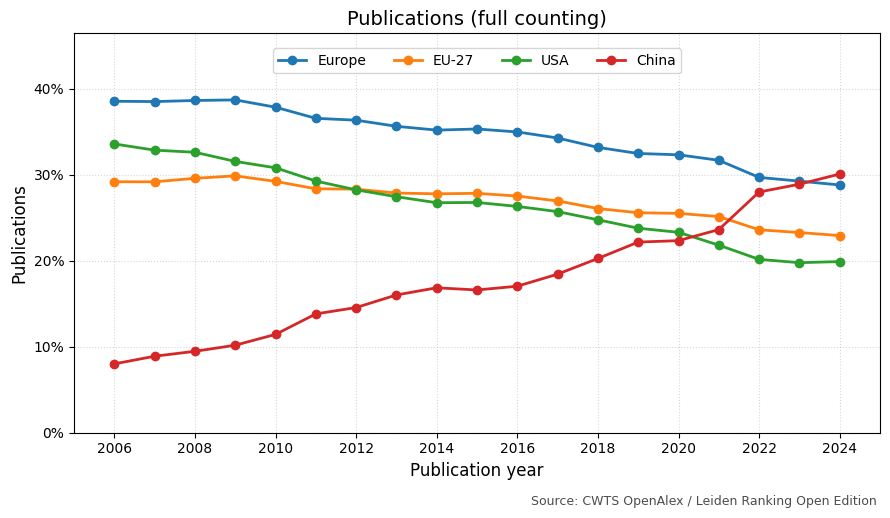

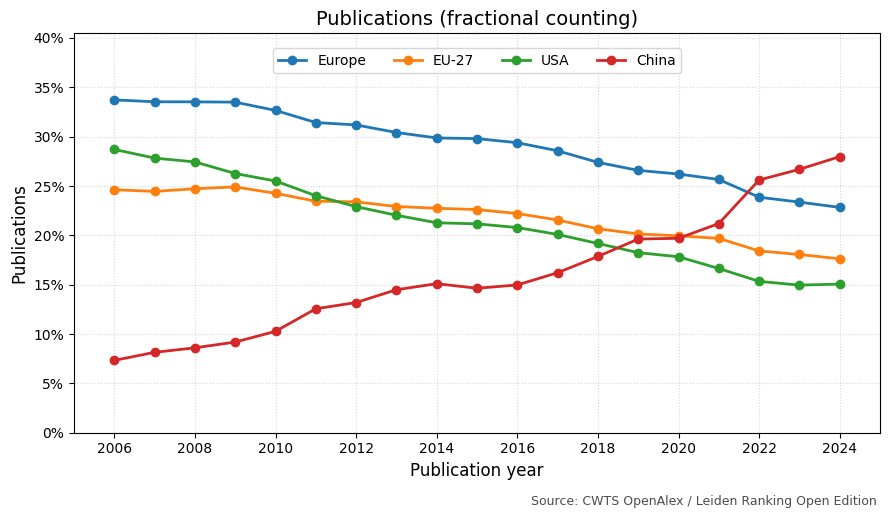

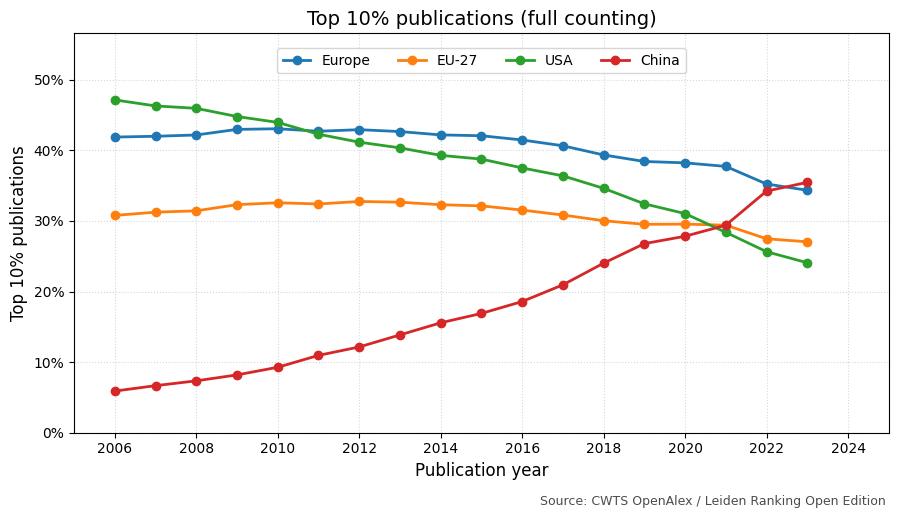

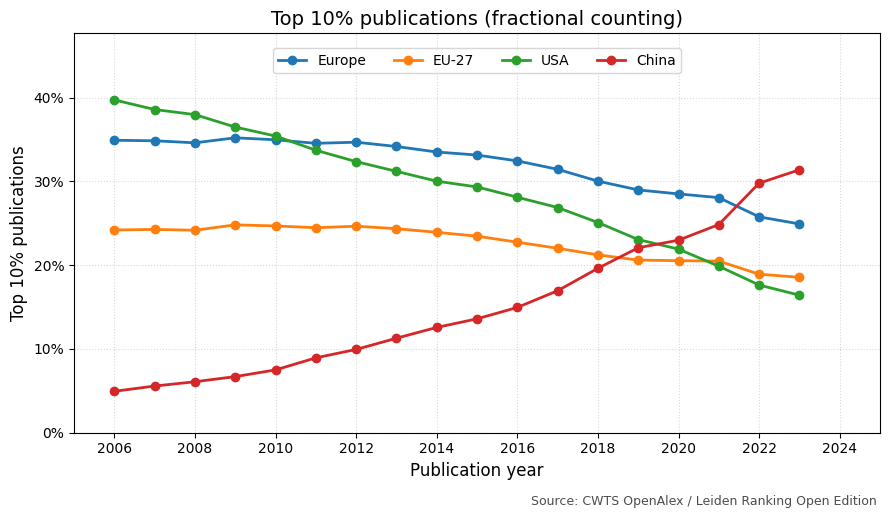

In [16]:
plot_lines(
    df_full_p,
    ['pp_europe','pp_eu27','pp_us','pp_china'],
    ['Europe','EU-27','USA','China'],
    "Publications (full counting)",
    "Publications",
    filename="full_p_country_groupings.png"
)
plot_lines(
    df_frac_p,
    ['pp_europe','pp_eu27','pp_us','pp_china'],
    ['Europe','EU-27','USA','China'],
    "Publications (fractional counting)",
    "Publications",
    filename="frac_p_country_groupings.png"
)

plot_lines(
    df_full_p_top_10,
    ['pp_top_10_europe','pp_top_10_eu27','pp_top_10_us','pp_top_10_china'],
    ['Europe','EU-27','USA','China'],
    "Top 10% publications (full counting)",
    "Top 10% publications",
    filename="full_p_top_10%_country_groupings.png"
)
plot_lines(
    df_frac_p_top_10,
    ['pp_top_10_europe','pp_top_10_eu27','pp_top_10_us','pp_top_10_china'],
    ['Europe','EU-27','USA','China'],
    "Top 10% publications (fractional counting)",
    "Top 10% publications",
    filename="frac_p_top_10%_country_groupings.png"
)

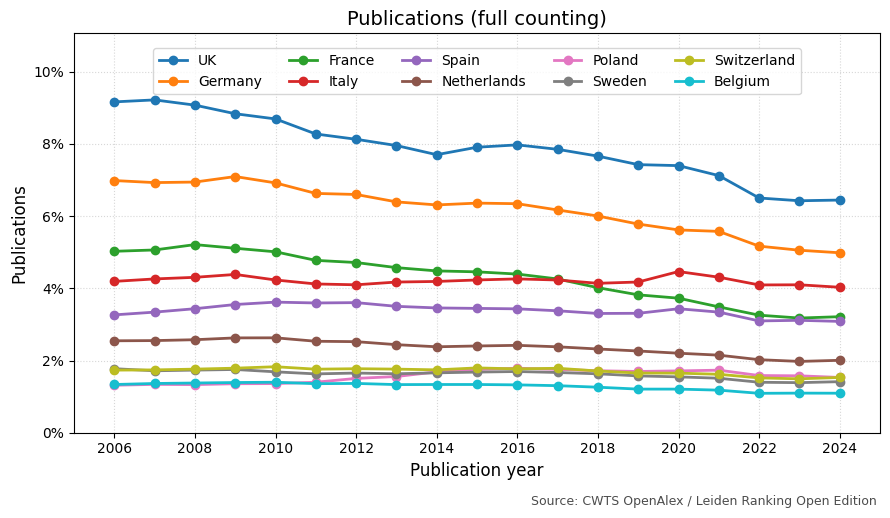

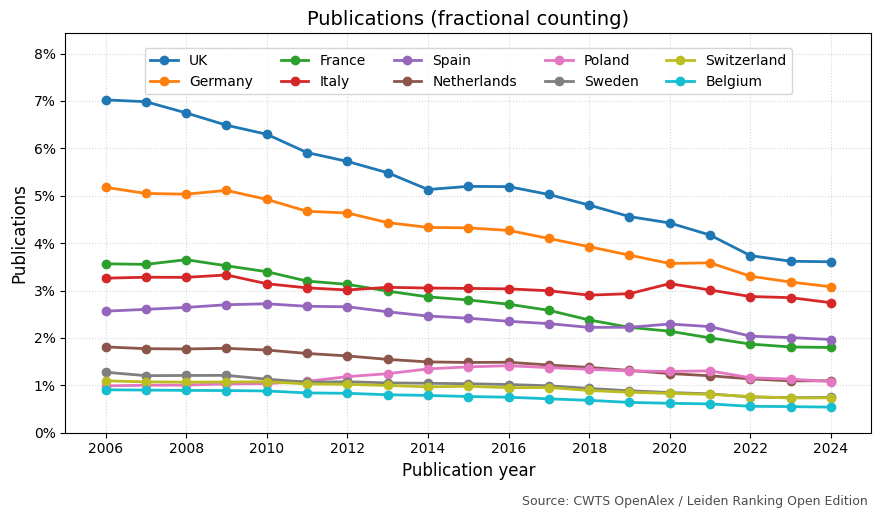

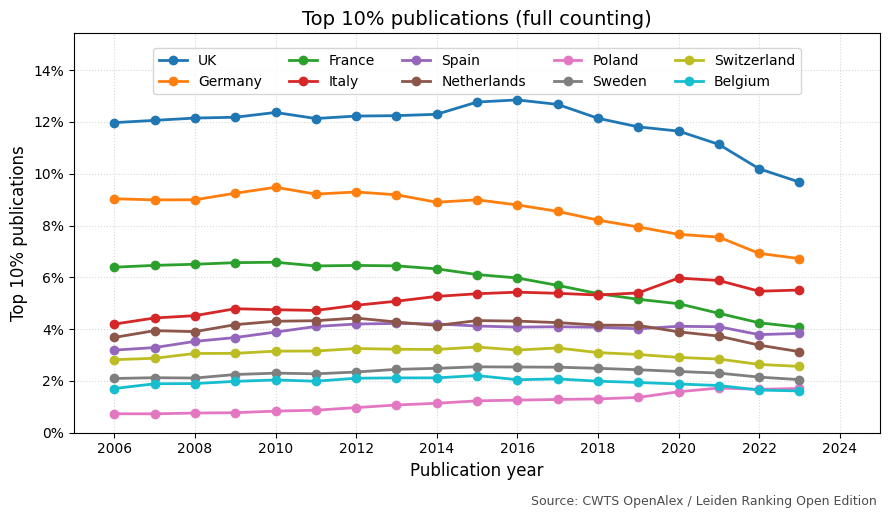

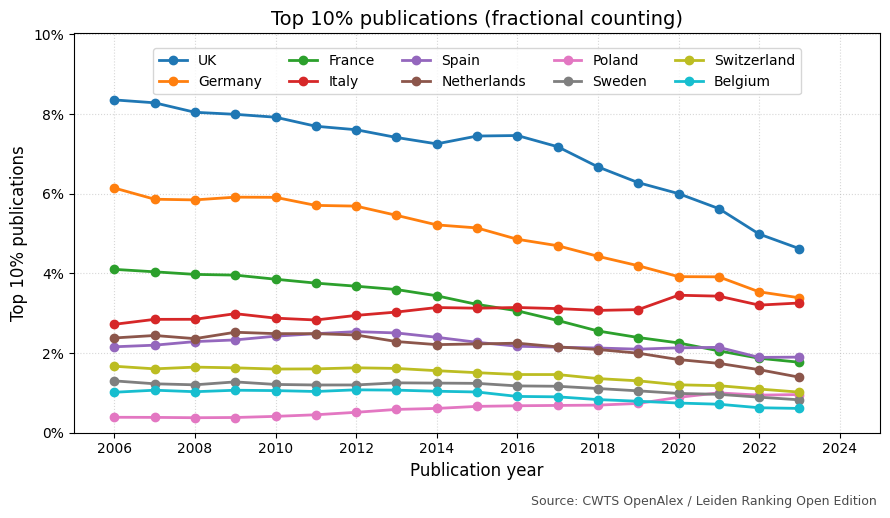

In [17]:
plot_lines(
    df_full_p,
    ['pp_uk','pp_germany','pp_france','pp_italy','pp_spain',
     'pp_netherlands','pp_poland','pp_sweden','pp_switzerland','pp_belgium'],
    ['UK','Germany','France','Italy','Spain',
     'Netherlands','Poland','Sweden','Switzerland','Belgium'],
    "Publications (full counting)",
    "Publications",
    filename="full_p_european_countries.png"
)
plot_lines(
    df_frac_p,
    ['pp_uk','pp_germany','pp_france','pp_italy','pp_spain',
     'pp_netherlands','pp_poland','pp_sweden','pp_switzerland','pp_belgium'],
    ['UK','Germany','France','Italy','Spain',
     'Netherlands','Poland','Sweden','Switzerland','Belgium'],
    "Publications (fractional counting)",
    "Publications",
    filename="frac_p_european_countries.png"
)

plot_lines(
    df_full_p_top_10,
    ['pp_top_10_uk','pp_top_10_germany','pp_top_10_france','pp_top_10_italy',
     'pp_top_10_spain','pp_top_10_netherlands','pp_top_10_poland',
     'pp_top_10_sweden','pp_top_10_switzerland','pp_top_10_belgium'],
    ['UK','Germany','France','Italy',
     'Spain','Netherlands','Poland','Sweden','Switzerland','Belgium'],
    "Top 10% publications (full counting)",
    "Top 10% publications",
    filename="full_p_top_10%_european_countries.png"
)
plot_lines(
    df_frac_p_top_10,
    ['pp_top_10_uk','pp_top_10_germany','pp_top_10_france','pp_top_10_italy',
     'pp_top_10_spain','pp_top_10_netherlands','pp_top_10_poland',
     'pp_top_10_sweden','pp_top_10_switzerland','pp_top_10_belgium'],
    ['UK','Germany','France','Italy',
     'Spain','Netherlands','Poland','Sweden','Switzerland','Belgium'],
    "Top 10% publications (fractional counting)",
    "Top 10% publications",
    filename="frac_p_top_10%_european_countries.png"
)